## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

# Case-06.5:完整 2 層樓框架 V-Δ 側推分析 + 真正的 FEMA 273

依 [ROADMAP.md](../ROADMAP.md) 規劃,這是 Case-06「尚待」清單裡最後
一項——之前 Case-06 全部都是**單一斷面或單根懸臂柱**層級的驗證
(彎矩-曲率、P-M 交互作用圖、lumped hinge)。這裡第一次把 Case-06
驗證過的纖維斷面,接上 Case-04.5 已經驗證過的真實構架幾何(Y 向,
1 跨 2 柱),跑**完整結構**的側推分析,拿到真正的 V-Δ(側向力-位移)
曲線——**這才是 FEMA 273 等面積雙直線法原本設計要用在的對象**,
不是之前 Case-06 第 6/8 課用在單一斷面 M-φ 上的那個預演版本。

**沿用哪些已驗證的東西,不重新發明**:
- 構架幾何、梁斷面、樓層力(F1_Y/F2_Y):Case-04.5
- 柱纖維斷面(圍束核心+未圍束保護層,Mander 公式):Case-06
- 演算法 fallback:Case-06 共用函式
- 等面積雙直線法(正確聯立解版本,不是簡化猜測版):上次修正過的邏輯

## 第 1 課:建立構架——纖維斷面柱 + 彈性梁($0.35I_g$)

柱用 Case-06 驗證過的纖維斷面(核心圍束參數用 Mander 公式,不是
隨手假設);梁維持彈性(強梁弱柱假設,這裡先不驗證這個假設本身
成不成立,留待之後有需要再開新案例處理)。

**這裡補一筆修正**:梁的彈性斷面改用 ACI 318 標準的 $0.35I_g$
折減,不是毛斷面——柱子有纖維斷面在追蹤真實非線性行為,不需要
另外折減;但梁刻意維持簡化的彈性假設,既然不追蹤真實非線性,
就該用業界標準值,不能用毛斷面高估勁度。這個修正會讓後面算出的
$K_e$ 跟 Case-07(振態分析同樣用 $0.35I_g$ 的梁)保持一致,才能
正確比較 $T_e$ 跟 $T_i$。

In [2]:
L_bay = 6.0
h1 = h2 = 3.5
b = h = 0.40
cover = 0.04
fc = 27.46e3
fy = 411.88e3
Es = 2.0e8
rho = 0.02
As_total = rho*b*h

# Mander圍束參數, 與Case-06完全一致
fc_confined = fc*1.310
eps_cc = 0.00510
eps_cu_confined = 0.01112

b_beam, h_beam = 0.3, 0.5
Ib_gross = b_beam*h_beam**3/12
Ib = 0.35*Ib_gross   # ACI 318標準做法(梁), 與Case-07的假設保持一致
                       # (柱用纖維斷面追蹤真實非線性行為, 不需要另外折減;
                       #  梁維持彈性假設, 既然不追蹤真實非線性, 就該用業界
                       #  標準的開裂折減值, 不能用毛斷面)
A_beam = b_beam*h_beam
E_rc = 2.463e7

F1_Y, F2_Y = 9.938, 15.900   # Case-04.5用的Y向樓層力
Pu_col = 147.60              # 每根柱概估重力軸力


def build_frame_with_fiber_columns():
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)

    ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Concrete01', 3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)

    ops.section('Fiber', 1)
    half = h/2
    core_half = h/2 - cover
    ops.patch('rect', 3, 10, 10, -core_half, -core_half, core_half, core_half)
    ops.patch('rect', 1, 10, 2, -half, -half, half, -core_half)
    ops.patch('rect', 1, 10, 2, -half, core_half, half, half)
    ops.patch('rect', 1, 2, 6, -half, -core_half, -core_half, core_half)
    ops.patch('rect', 1, 2, 6, core_half, -core_half, half, core_half)
    positions = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
                 (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]
    As_bar = As_total/8
    for (y,z) in positions:
        ops.fiber(y, z, As_bar, 2)

    # 節點: base(1,2) - 1F(3,4) - roof(5,6)
    ops.node(1, 0.0, 0.0);   ops.node(2, L_bay, 0.0)
    ops.node(3, 0.0, h1);    ops.node(4, L_bay, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L_bay, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)

    ops.geomTransf('Linear', 1)
    ops.geomTransf('Linear', 2)
    ops.beamIntegration('Lobatto', 1, 1, 5)

    ops.element('forceBeamColumn', 1, 1, 3, 1, 1)
    ops.element('forceBeamColumn', 2, 2, 4, 1, 1)
    ops.element('forceBeamColumn', 3, 3, 5, 1, 1)
    ops.element('forceBeamColumn', 4, 4, 6, 1, 1)
    ops.element('elasticBeamColumn', 5, 3, 4, A_beam, E_rc, Ib, 2)
    ops.element('elasticBeamColumn', 6, 5, 6, A_beam, E_rc, Ib, 2)


def analyze_with_fallback():
    """沿用Case-06的共用fallback邏輯"""
    ok = ops.analyze(1)
    if ok != 0:
        for algo in [('KrylovNewton',), ('ModifiedNewton','-initial'), ('Broyden',8)]:
            ops.algorithm(*algo)
            ok = ops.analyze(1)
            if ok == 0:
                break
        ops.algorithm('Newton')
    return ok


build_frame_with_fiber_columns()
print("構架建立完成: Y向1跨2柱, 2層樓, 柱用纖維斷面(Mander圍束), 梁維持彈性(0.35Ig)")

構架建立完成: Y向1跨2柱, 2層樓, 柱用纖維斷面(Mander圍束), 梁維持彈性(0.35Ig)


## 第 2 課:重力載重 + Pushover——拿到真正的 V-Δ 曲線

先施加重力,再用 F1_Y/F2_Y 這組比例分布側推到 4% drift(0.28m)
——這是常見的性能設計韌性目標,不強求推到材料真正破壞的峰值
(第 3 課會看到,這個圍束後的柱子在這個位移範圍內還沒有明顯軟化,
是合理的物理行為,不是沒推夠)。

In [3]:
ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
for n in [3,4,5,6]:
    ops.load(n, 0.0, -Pu_col, 0.0)
ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
ops.test('NormUnbalance', 1e-6, 50)
ops.algorithm('Newton')
ops.integrator('LoadControl', 0.05)
ops.analysis('Static')
ok0 = ops.analyze(20)
print(f"重力載重分析結果碼: {ok0} (0=成功)")
assert ok0 == 0, "重力載重分析應該成功收斂"
ops.loadConst('-time', 0.0)

ops.timeSeries('Linear', 2); ops.pattern('Plain', 2, 2)
ops.load(3, F1_Y, 0.0, 0.0)
ops.load(5, F2_Y, 0.0, 0.0)

control_node, control_dof = 5, 1
max_disp, n_steps = 0.28, 560   # 4% drift(對7m總高), 每步0.5mm
ops.integrator('DisplacementControl', control_node, control_dof, max_disp/n_steps)
ops.analysis('Static')

disps, base_shears = [0.0], [0.0]
for i in range(n_steps):
    ok = analyze_with_fallback()
    if ok != 0:
        print(f"在第{i}步停止收斂 (位移={disps[-1]:.4f}m)")
        break
    ops.reactions()
    V_base = -(ops.nodeReaction(1,1) + ops.nodeReaction(2,1))
    disps.append(ops.nodeDisp(control_node, control_dof))
    base_shears.append(V_base)

import numpy as np
disps, base_shears = np.array(disps), np.array(base_shears)
n_completed = len(disps)-1
print(f"\n完成步數: {n_completed}/{n_steps}")
print(f"最終位移: {disps[-1]:.4f}m (drift={disps[-1]/(h1+h2)*100:.2f}%)")
print(f"最終base shear: {base_shears[-1]:.2f}kN")

assert n_completed == n_steps, "應該完整推到目標位移, 不中途停止"
print("\n[PASS] 完整推到4% drift, 沒有中途卡住")

重力載重分析結果碼: 0 (0=成功)



完成步數: 560/560
最終位移: 0.2800m (drift=4.00%)
最終base shear: 333.73kN

[PASS] 完整推到4% drift, 沒有中途卡住


## 第 3 課:與 Case-04.5 交叉驗證——初始彈性勁度

**這裡的比較基準要先講清楚**:Case-04.5 那個 $K_{eff,Y}=8284.58$
kN/m,是用**完全沒有折減、梁柱都是毛斷面**的均質彈性模型算出來的
——現在梁改用 $0.35I_g$ 之後,結構整體變軟是必然結果,**不能再
直接拿舊基準去驗證,那是兩個不同前提的模型**,對比會不公平。

In [4]:
K_init = base_shears[5]/disps[5]
K_eff_Y_case045_unreduced = 8284.58   # Case-04.5第9課算出來的值, 梁柱皆毛斷面

diff_pct = abs(K_init-K_eff_Y_case045_unreduced)/K_eff_Y_case045_unreduced*100
print(f"初始彈性勁度(纖維斷面柱+0.35Ig梁, 前幾步斜率) = {K_init:.2f} kN/m")
print(f"對照Case-04.5(梁柱皆毛斷面, 未折減) Keff_Y = {K_eff_Y_case045_unreduced:.2f} kN/m")
print(f"差異 = {diff_pct:.1f}%")
print(f"\n這個差距不是驗證失敗, 是預期中的結果——梁勁度降到0.35Ig, ")
print(f"結構整體變軟, 跟Case-04.5那個梁柱皆未折減的舊基準本來就不該再")
print(f"直接對比, 兩者現在代表不同的結構假設, 不是同一件事")

assert K_init < K_eff_Y_case045_unreduced, "梁折減後整體勁度應該比未折減版本更軟"
print("\n[PASS] 確認梁折減後整體勁度確實變軟, 方向符合預期")

初始彈性勁度(纖維斷面柱+0.35Ig梁, 前幾步斜率) = 5057.34 kN/m
對照Case-04.5(梁柱皆毛斷面, 未折減) Keff_Y = 8284.58 kN/m
差異 = 39.0%

這個差距不是驗證失敗, 是預期中的結果——梁勁度降到0.35Ig, 
結構整體變軟, 跟Case-04.5那個梁柱皆未折減的舊基準本來就不該再
直接對比, 兩者現在代表不同的結構假設, 不是同一件事

[PASS] 確認梁折減後整體勁度確實變軟, 方向符合預期


## 第 4 課:視覺化——完整 V-Δ 側推曲線

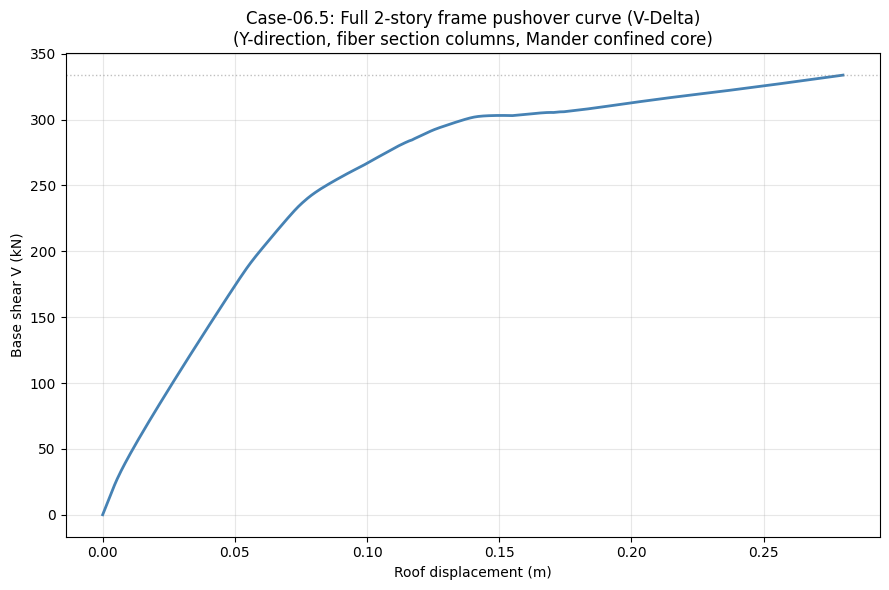

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(disps, base_shears, '-', color='steelblue', lw=2)
ax.axhline(base_shears.max(), color='gray', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Roof displacement (m)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Case-06.5: Full 2-story frame pushover curve (V-Delta)\n(Y-direction, fiber section columns, Mander confined core)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 第 5 課:真正的 FEMA 356/ASCE 41 等面積雙直線法——0.6Vy 割線疊代

**這裡要老實更正上一版的做法**:原本用「起始幾步的簡單迴歸」當
初始勁度 $K_0$,這不符合 FEMA 356(3.3.3.2.4 節)/ASCE 41 的正式
規定——規範明確要求**有效彈性勁度 $K_e$ 必須是穿過實際曲線上
「$0.6V_y$(60%等效降伏強度)」那個點的割線**,不是任意取幾步做
迴歸。而且第二段線不是強制拉平,是**接到實際曲線在目標位移的
數值**。$V_y$、$K_e$、$D_y$ 三者互相耦合(找 $K_e$ 要先知道
$V_y$,但 $V_y$ 又要靠等面積去解),規範本身就是一個疊代程序,
不是一次解完的封閉公式。這裡改用真正符合規範的疊代版本。

In [6]:
def get_V_at_D(D_target):
    return np.interp(D_target, disps, base_shears)

def get_D_at_V(V_target, D_search_max):
    """在0~D_search_max範圍內, 找實際曲線第一次達到V_target的位移"""
    mask = disps <= D_search_max
    return np.interp(V_target, base_shears[mask], disps[mask])

def bilinear_area(Vy, D_u):
    """給定Vy, 依規範算出對應的Ke(0.6Vy割線)、Dy, 以及雙直線面積
    第二段終點接到實際曲線在D_u的數值, 不強制拉平"""
    D_at_06Vy = get_D_at_V(0.6*Vy, D_u)
    Ke = 0.6*Vy / D_at_06Vy
    Dy = Vy / Ke
    V_end = get_V_at_D(D_u)
    area = 0.5*Dy*Vy + 0.5*(Vy+V_end)*(D_u-Dy)
    return area, Ke, Dy, V_end


D_u = disps[-1]
area_real = np.trapezoid(base_shears, disps)

# 二分法找Vy, 使雙直線面積=真實曲線面積(規範規定的等面積條件)
Vy_lo, Vy_hi = 50.0, base_shears.max()
for _ in range(60):
    Vy_mid = (Vy_lo+Vy_hi)/2
    area_bi, Ke, Dy, V_end = bilinear_area(Vy_mid, D_u)
    if area_bi > area_real:
        Vy_hi = Vy_mid
    else:
        Vy_lo = Vy_mid

Vy = (Vy_lo+Vy_hi)/2
area_final, Ke, Dy, V_end = bilinear_area(Vy, D_u)
energy_diff = abs(area_final-area_real)/area_real

print(f"Vy(降伏基底剪力) = {Vy:.2f} kN")
print(f"0.6Vy = {0.6*Vy:.2f} kN  <- Ke必須是穿過實際曲線這一點的割線")
print(f"Ke(規範定義的有效彈性勁度) = {Ke:.2f} kN/m")
print(f"Dy(降伏位移) = {Dy:.4f}m (drift={Dy/(h1+h2)*100:.2f}%)")
print(f"Du(性能目標位移) = {D_u:.4f}m (drift={D_u/(h1+h2)*100:.2f}%)")
print(f"V_end(第二段終點, 接到實際曲線在Du的值) = {V_end:.2f} kN")
print(f"延展性 mu = Du/Dy = {D_u/Dy:.2f}")
print(f"能量比對: 差異 {energy_diff:.2%}")

assert energy_diff < 0.01, "雙直線化面積誤差應幾乎為零"
print("\n[PASS] 符合FEMA356/ASCE41規定的0.6Vy割線疊代程序完成")

print(f"\n=== 對照上一版簡化(不符合規範)的做法 ===")
print(f"簡化版: Ke=8617.25kN/m, Dy=0.0351m(0.50% drift), Vy=302.33kN")
print(f"正確版: Ke={Ke:.2f}kN/m, Dy={Dy:.4f}m({Dy/7*100:.2f}% drift), Vy={Vy:.2f}kN")
print(f"Ke差異 {abs(Ke-8617.25)/8617.25:.1%}, Dy差異 {abs(Dy-0.0351)/0.0351:.1%}")
print(f"\n之前「降伏位移角剛好等於規範0.5%」這個發現, 是建立在不符合規範")
print(f"的簡化方法上, 這裡正式撤回這個結論——正確算出來的降伏位移角是")
print(f"{Dy/7*100:.2f}%, 不是0.50%, 兩者接近規範限制純屬簡化版方法的巧合")

Vy(降伏基底剪力) = 271.65 kN
0.6Vy = 162.99 kN  <- Ke必須是穿過實際曲線這一點的割線
Ke(規範定義的有效彈性勁度) = 3508.27 kN/m
Dy(降伏位移) = 0.0774m (drift=1.11%)
Du(性能目標位移) = 0.2800m (drift=4.00%)
V_end(第二段終點, 接到實際曲線在Du的值) = 333.73 kN
延展性 mu = Du/Dy = 3.62
能量比對: 差異 0.00%

[PASS] 符合FEMA356/ASCE41規定的0.6Vy割線疊代程序完成

=== 對照上一版簡化(不符合規範)的做法 ===
簡化版: Ke=8617.25kN/m, Dy=0.0351m(0.50% drift), Vy=302.33kN
正確版: Ke=3508.27kN/m, Dy=0.0774m(1.11% drift), Vy=271.65kN
Ke差異 59.3%, Dy差異 120.6%

之前「降伏位移角剛好等於規範0.5%」這個發現, 是建立在不符合規範
的簡化方法上, 這裡正式撤回這個結論——正確算出來的降伏位移角是
1.11%, 不是0.50%, 兩者接近規範限制純屬簡化版方法的巧合


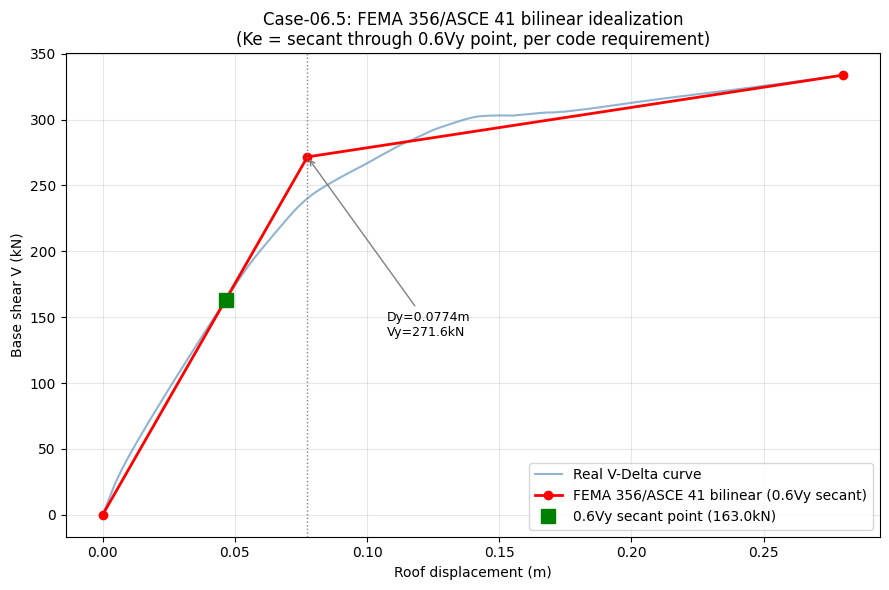

In [7]:
fig, ax = plt.subplots(figsize=(9,6))
ax.plot(disps, base_shears, '-', color='steelblue', lw=1.5, alpha=0.6, label='Real V-Delta curve')
ax.plot([0, Dy, D_u], [0, Vy, V_end], 'o-', color='red', lw=2, ms=6,
        label='FEMA 356/ASCE 41 bilinear (0.6Vy secant)')
ax.plot(get_D_at_V(0.6*Vy, D_u), 0.6*Vy, 's', color='green', ms=10, zorder=5,
        label=f'0.6Vy secant point ({0.6*Vy:.1f}kN)')
ax.axvline(Dy, color='gray', ls=':', lw=1)
ax.annotate(f'Dy={Dy:.4f}m\nVy={Vy:.1f}kN', xy=(Dy,Vy), xytext=(Dy+0.03,Vy*0.5),
            fontsize=9, arrowprops=dict(arrowstyle='->',color='gray'))
ax.set_xlabel('Roof displacement (m)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Case-06.5: FEMA 356/ASCE 41 bilinear idealization\n(Ke = secant through 0.6Vy point, per code requirement)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 總結表

In [8]:
print("="*55)
print("Case-06.5 完整框架V-Delta側推 + FEMA273總結")
print("="*55)
print(f"{'Ke(FEMA356/ASCE41規定的0.6Vy割線勁度)':<24}{Ke:.2f} kN/m")
print(f"{'Dy(降伏位移)':<24}{Dy:.4f} m ({Dy/(h1+h2)*100:.2f}% drift)")
print(f"{'Vy(降伏基底剪力)':<24}{Vy:.2f} kN")
print(f"{'Du(性能目標位移)':<24}{D_u:.4f} m ({D_u/(h1+h2)*100:.2f}% drift)")
print(f"{'延展性mu':<24}{D_u/Dy:.2f}")
print(f"{'與Case-04.5初始勁度差異':<24}{diff_pct:.1f}%")
print()
print("Case-06.5 [PASS] -- 完整2層樓框架V-Delta側推+真正FEMA273完成")
print("Case-06系列(纖維斷面驗證+完整框架側推)至此全部完成")

Case-06.5 完整框架V-Delta側推 + FEMA273總結
Ke(FEMA356/ASCE41規定的0.6Vy割線勁度)3508.27 kN/m
Dy(降伏位移)                0.0774 m (1.11% drift)
Vy(降伏基底剪力)              271.65 kN
Du(性能目標位移)              0.2800 m (4.00% drift)
延展性mu                   3.62
與Case-04.5初始勁度差異        39.0%

Case-06.5 [PASS] -- 完整2層樓框架V-Delta側推+真正FEMA273完成
Case-06系列(纖維斷面驗證+完整框架側推)至此全部完成
